## Visão Computacional - PPGCC/UNIFESP
## Projeto Final

### Trabalho: EEG2Image-JEPA - Geração de Imagens a partir de EEG via Joint Embedding Predictive Archtecture (JEPA)

#### Prof: Prof. Fabio Augusto M. Cappabianco
#### Aluno: Felipe Faustino Brito

In [1]:
# ===== Célula 1 — Setup =====
# O Colab já traz torch com CUDA. Só precisamos do MOABB (que puxa o MNE).
!pip install -q moabb

import random
import numpy as np
import torch

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)

import moabb
print("moabb:", moabb.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.3/255.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
torch: 2.11.0+cu128 | device: cuda
moabb: 1.5.0


In [2]:
# ===== Célula 2 — BNCI2014_001, within-subject, 3 classes =====
import mne
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

mne.set_log_level("WARNING"); moabb.set_log_level("warning")

SUBJECT = 1
CLASSES = ["right_hand", "feet", "tongue"]    # reutiliza 2 pastas + 1 nova (tongue)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

dataset  = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=4.0, fmax=40.0, resample=128.0)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[SUBJECT])

# Filtra para o subconjunto de classes
labels = np.asarray(y)
mask = np.isin(labels, CLASSES)
X = X[mask].astype("float32"); labels = labels[mask]
metadata = metadata[mask].reset_index(drop=True)

uniq, counts = np.unique(labels, return_counts=True)
print("X shape:", X.shape, "| por classe:", dict(zip(uniq, counts.tolist())))

y_idx = np.array([CLASS_TO_IDX[c] for c in labels], dtype="int64")

sessions = np.asarray(metadata["session"]); sess = sorted(np.unique(sessions))
train_idx = np.where(sessions == sess[0])[0]
val_idx   = np.where(sessions == sess[1])[0]

eeg_t, y_t = torch.from_numpy(X), torch.from_numpy(y_idx)
N_TRIALS, N_CHANS, N_TIMES = X.shape
print(f"Treino (sessão {sess[0]}): {len(train_idx)} | Val (sessão {sess[1]}): {len(val_idx)}")
print(f"N_CHANS={N_CHANS}, N_TIMES={N_TIMES}, N_CLASSES={len(CLASSES)}")

/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


X shape: (432, 22, 513) | por classe: {np.str_('feet'): 144, np.str_('right_hand'): 144, np.str_('tongue'): 144}
Treino (sessão 0train): 216 | Val (sessão 1test): 216
N_CHANS=22, N_TIMES=513, N_CLASSES=3


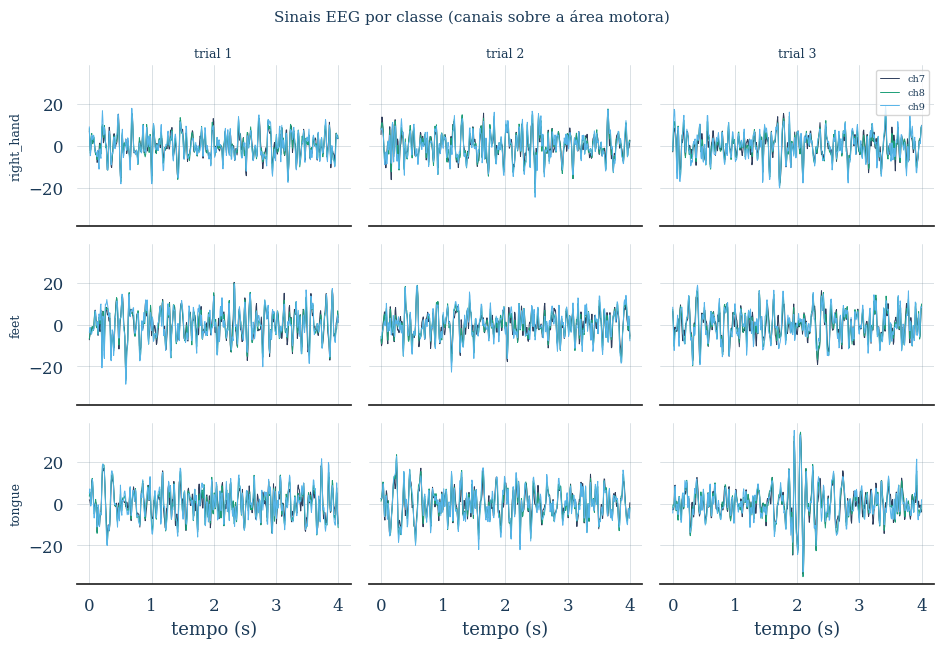

Trials por classe: [144 144 144] | canais: 22 | amostras: 513


In [3]:
# ===== Célula 2b — Visualizar sinais EEG por classe =====
# (rode DEPOIS da célula 2, que cria eeg_t / y_t / CLASSES)
import matplotlib.pyplot as plt

N_TRIALS_SHOW = 3        # quantos trials por classe
CHANS_SHOW    = [7, 8, 9]  # índices de canais a sobrepor (ex.: C3, Cz, C4 — área motora)
SFREQ = 128              # Hz (após o resample da célula 2)
t_axis = np.arange(N_TIMES) / SFREQ

fig, axes = plt.subplots(len(CLASSES), N_TRIALS_SHOW,
                         figsize=(N_TRIALS_SHOW*3.2, len(CLASSES)*2.2), sharex=True, sharey=True)
for r, cname in enumerate(CLASSES):
    idx = np.where(y_t.numpy() == r)[0][:N_TRIALS_SHOW]   # primeiros trials da classe
    for k, ti in enumerate(idx):
        ax = axes[r, k] if len(CLASSES) > 1 else axes[k]
        for ch in CHANS_SHOW:
            ax.plot(t_axis, eeg_t[ti, ch].numpy(), lw=0.7, label=f"ch{ch}")
        if k == 0: ax.set_ylabel(cname, fontsize=9)
        if r == 0: ax.set_title(f"trial {k+1}", fontsize=9)
        if r == len(CLASSES)-1: ax.set_xlabel("tempo (s)")
        ax.grid(alpha=0.3)
axes[0, -1].legend(fontsize=7, loc="upper right")
fig.suptitle("Sinais EEG por classe (canais sobre a área motora)", fontsize=11)
plt.tight_layout(); plt.show()

print("Trials por classe:", np.bincount(y_t.numpy()), "| canais:", N_CHANS, "| amostras:", N_TIMES)

In [4]:
# Opção A — subir um .zip e descompactar (rode no Colab, ajuste o nome do zip):
from google.colab import files; files.upload()          # sobe o images.zip
!unzip -q images.zip -d /content/images
#
# Opção B — montar o Google Drive:
# from google.colab import drive; drive.mount('/content/drive')
# e aponte IMAGE_ROOT para a pasta no Drive.

Saving images.zip to images.zip


right_hand: 55 imagens -> 50 treino / 5 teste
feet      : 55 imagens -> 50 treino / 5 teste
tongue    : 55 imagens -> 50 treino / 5 teste


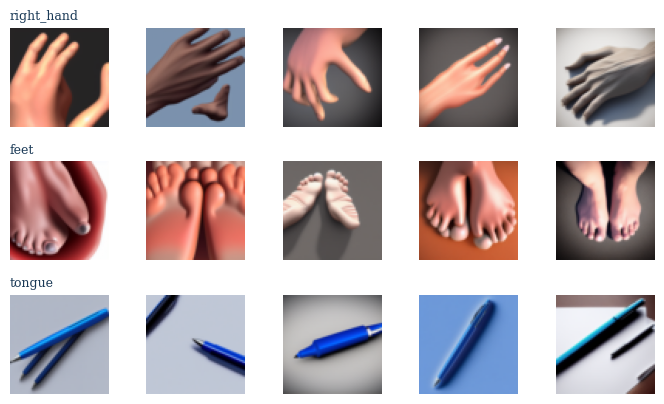

In [6]:
# ===== Célula 3 — Imagens-alvo por classe =====
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = 64
IMAGE_ROOT = Path("/content/images")   # ajuste se usar o Drive
N_TEST_PER_CLASS = 5                   # imagens-alvo nunca vistas no treino
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

def load_class_images(folder):
    paths = sorted(p for p in folder.iterdir() if p.suffix.lower() in EXTS)
    imgs = []
    for p in paths:
        img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr = np.asarray(img, dtype="float32") / 255.0      # [0,1], (H,W,3)
        imgs.append(arr.transpose(2, 0, 1))                 # -> (3,H,W)
    return torch.from_numpy(np.stack(imgs)) if imgs else torch.empty(0, 3, IMG_SIZE, IMG_SIZE)

images_train, images_test = {}, {}
rng = np.random.default_rng(SEED)
for c in CLASSES:
    folder = IMAGE_ROOT / c
    assert folder.exists(), f"Pasta não encontrada: {folder} (crie e suba as imagens)"
    imgs = load_class_images(folder)
    n = imgs.shape[0]
    assert n > N_TEST_PER_CLASS, f"Classe '{c}' tem só {n} imagens"
    perm = rng.permutation(n)
    ci = CLASS_TO_IDX[c]
    images_test[ci]  = imgs[perm[:N_TEST_PER_CLASS]].contiguous()
    images_train[ci] = imgs[perm[N_TEST_PER_CLASS:]].contiguous()
    print(f"{c:10s}: {n} imagens -> {images_train[ci].shape[0]} treino / {images_test[ci].shape[0]} teste")

# Sanidade visual: algumas imagens por classe
ncol = 5
fig, axes = plt.subplots(len(CLASSES), ncol, figsize=(ncol*1.4, len(CLASSES)*1.4))
for r, c in enumerate(CLASSES):
    pool = images_train[CLASS_TO_IDX[c]]
    for k in range(ncol):
        ax = axes[r, k]
        ax.axis("off")
        if k < pool.shape[0]:
            ax.imshow(pool[k].permute(1, 2, 0).numpy())
        if k == 0:
            ax.set_title(c, loc="left", fontsize=9)
plt.tight_layout(); plt.show()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

CLIP_DIM / LATENT_DIM: 768


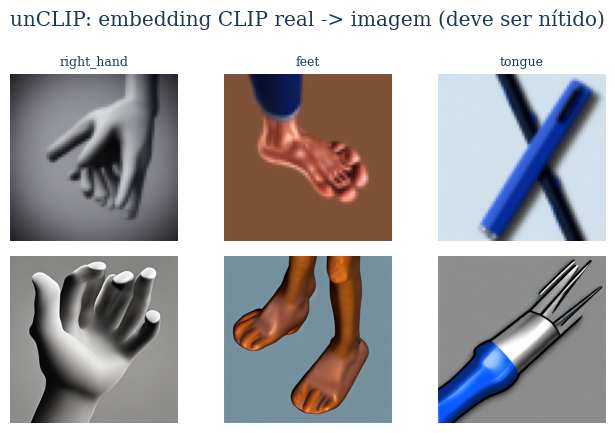

sy_train[0]: (50, 768)


In [7]:
# ===== Célula 4 — unCLIP + embeddings CLIP (alvos) + prova =====
!pip install -q diffusers transformers accelerate
from PIL import Image
from diffusers import StableUnCLIPImg2ImgPipeline

pipe = StableUnCLIPImg2ImgPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-1-unclip-small", torch_dtype=torch.float16,
).to(device)
pipe.set_progress_bar_config(disable=True); pipe.enable_attention_slicing()
for p in pipe.image_encoder.parameters(): p.requires_grad_(False)

CLIP_DIM = pipe.image_encoder.config.projection_dim
LATENT_DIM = CLIP_DIM                       # alvo do predictor (definido AQUI, antes da arquitetura)
print("CLIP_DIM / LATENT_DIM:", CLIP_DIM)

def to_pil(t): return Image.fromarray((t.permute(1,2,0).numpy()*255).astype("uint8"))

@torch.no_grad()
def clip_encode(imgs01, bs=8):
    outs = []
    for i in range(0, imgs01.shape[0], bs):
        pil = [to_pil(im) for im in imgs01[i:i+bs]]
        inp = pipe.feature_extractor(images=pil, return_tensors="pt").to(device, torch.float16)
        outs.append(pipe.image_encoder(**inp).image_embeds.float().cpu())
    return torch.cat(outs)

@torch.no_grad()
def unclip_generate(embeds, steps=20, guidance=10.0, seed=0):
    imgs = []
    for i in range(embeds.shape[0]):
        g = torch.Generator(device=device).manual_seed(seed+i)
        out = pipe(image_embeds=embeds[i:i+1].to(device, torch.float16),
                   noise_level=0, num_inference_steps=steps, guidance_scale=guidance, generator=g)
        imgs.append(out.images[0])
    return imgs

# Embeddings CLIP CRUS das imagens-alvo
sy_train_raw = {c: clip_encode(images_train[c]) for c in range(len(CLASSES))}
sy_test_raw  = {c: clip_encode(images_test[c])  for c in range(len(CLASSES))}

# Prova: gerar a partir do embedding CRU de imagens de teste (deve sair nítido)
fig, axes = plt.subplots(2, len(CLASSES), figsize=(len(CLASSES)*2.2, 4.4))
for c in range(len(CLASSES)):
    gen = unclip_generate(sy_test_raw[c][:1], steps=25)[0]
    axes[0,c].imshow(images_test[c][0].permute(1,2,0)); axes[0,c].set_title(CLASSES[c], fontsize=9); axes[0,c].axis("off")
    axes[1,c].imshow(gen); axes[1,c].axis("off")
plt.suptitle("unCLIP: embedding CLIP real -> imagem (deve ser nítido)"); plt.tight_layout(); plt.show()

# Padronização (z-score) dos alvos para o treino
_pool = torch.cat([sy_train_raw[c] for c in range(len(CLASSES))])
SY_MEAN = _pool.mean(0, keepdim=True); SY_STD = _pool.std(0, keepdim=True) + 1e-6
sy_train = {c: (sy_train_raw[c]-SY_MEAN)/SY_STD for c in range(len(CLASSES))}
sy_test  = {c: (sy_test_raw[c]-SY_MEAN)/SY_STD for c in range(len(CLASSES))}
def unstd(x): return x*SY_STD.to(x.device) + SY_MEAN.to(x.device)   # volta à escala CLIP real
print("sy_train[0]:", tuple(sy_train[0].shape))

In [8]:
# ===== Célula 5 — Pares (EEG ↔ latente do VAE) + dataloaders =====
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 64

def normalize_eeg(x):                       # (C, T) -> z-score por canal
    m = x.mean(dim=1, keepdim=True); s = x.std(dim=1, keepdim=True) + 1e-6
    return (x - m) / s

class PairedEEGLatentDataset(Dataset):
    """1 trial de EEG + latente VAE de uma imagem aleatória da MESMA classe."""
    def __init__(self, eeg, labels, sy_by_class):
        self.eeg = eeg; self.labels = labels; self.sy = sy_by_class
    def __len__(self):
        return self.eeg.shape[0]
    def __getitem__(self, i):
        c = int(self.labels[i])
        eeg = normalize_eeg(self.eeg[i])
        pool = self.sy[c]
        j = torch.randint(pool.shape[0], (1,)).item()
        return eeg, pool[j].cpu(), c            # (C,T), (256,), classe

# train_idx / val_idx vêm da célula 2 (split por sessão)
ds_train = PairedEEGLatentDataset(eeg_t[train_idx], y_t[train_idx], sy_train)
ds_val   = PairedEEGLatentDataset(eeg_t[val_idx],   y_t[val_idx],   sy_train)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

print(f"Treino: {len(ds_train)} | Val: {len(ds_val)}")
eeg_b, sy_b, c_b = next(iter(dl_train))
print("eeg:", tuple(eeg_b.shape), "| latente:", tuple(sy_b.shape), "| labels:", tuple(c_b.shape))

Treino: 216 | Val: 216
eeg: (64, 22, 513) | latente: (64, 768) | labels: (64,)


In [9]:
# ===== Célula 6 — Arquitetura =====
import torch.nn as nn

D_EMB, Z_DIM = 128, 16   # LATENT_DIM (256) vem da célula do VAE

# XEncoder (EEGNet-8,2) — idêntico ao que já tínhamos
class XEncoder(nn.Module):
    def __init__(self, n_chans, n_times, F1=8, D=2, F2=16, kern_len=64, p_drop=0.5, d_emb=128):
        super().__init__()
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding="same", bias=False), nn.BatchNorm2d(F1))
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1*D, (n_chans, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(p_drop))
        self.separable = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1, 16), padding="same", groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(p_drop))
        with torch.no_grad():
            flat = self.separable(self.depthwise(self.firstconv(
                torch.zeros(1, 1, n_chans, n_times)))).flatten(1).shape[1]
        self.proj = nn.Linear(flat, d_emb)
    def forward(self, x):
        x = x.unsqueeze(1)
        return self.proj(self.separable(self.depthwise(self.firstconv(x))).flatten(1))

class Conditioner(nn.Module):       # posterior q(z | s_y) sobre o latente FIXO do VAE
    def __init__(self, latent_dim, z_dim=16, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, hidden), nn.SiLU(), nn.Linear(hidden, 2*z_dim))
    def forward(self, s_y):
        return self.net(s_y).chunk(2, dim=-1)            # mu, logvar

class Predictor(nn.Module):         # (s_x, z) -> latente do VAE
    def __init__(self, d_emb=128, z_dim=16, latent_dim=256, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_emb+z_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, latent_dim))
    def forward(self, s_x, z):
        return self.net(torch.cat([s_x, z], dim=-1))

class EEGJEPA(nn.Module):
    def __init__(self, n_chans, n_times, d_emb=128, z_dim=16, latent_dim=256):
        super().__init__()
        self.x_enc = XEncoder(n_chans, n_times, d_emb=d_emb)
        self.cond  = Conditioner(latent_dim, z_dim)
        self.predictor = Predictor(d_emb, z_dim, latent_dim)
        self.z_dim = z_dim
    @staticmethod
    def reparam(mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    def forward(self, eeg, s_y, z_dropout=0.5):
        s_x = self.x_enc(eeg)
        mu, logvar = self.cond(s_y)
        z = self.reparam(mu, logvar)
        if self.training and z_dropout > 0:                    # CFG-style
            d = (torch.rand(z.shape[0], 1, device=z.device) < z_dropout).float()
            z = d * torch.randn_like(z) + (1 - d) * z
        return dict(s_x=s_x, s_y_hat=self.predictor(s_x, z), mu=mu, logvar=logvar)
    @torch.no_grad()
    def generate(self, eeg, n_samples=1):
        self.eval()
        s_x = self.x_enc(eeg); outs = []
        for _ in range(n_samples):
            z = torch.randn(s_x.shape[0], self.z_dim, device=s_x.device)
            outs.append(self.predictor(s_x, z))               # latentes preditos
        return torch.stack(outs, dim=1)                       # (N, n_samples, 256)

model = EEGJEPA(N_CHANS, N_TIMES, D_EMB, Z_DIM, LATENT_DIM).to(device)
eeg_b, sy_b, c_b = next(iter(dl_train))
out = model(eeg_b.to(device), sy_b.to(device))
print("s_x:", tuple(out["s_x"].shape), "| ŝ_y:", tuple(out["s_y_hat"].shape))
print("params:", sum(p.numel() for p in model.parameters()))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


s_x: (64, 128) | ŝ_y: (64, 768)
params: 971344


In [10]:
# ===== Célula 8 — SIGReg + loss =====
import torch.nn as nn, torch.nn.functional as F

class SIGReg(nn.Module):
    def __init__(self, num_slices=1024, num_points=17):
        super().__init__()
        nodes, w = np.polynomial.hermite.hermgauss(num_points)
        self.register_buffer("t", torch.tensor(nodes, dtype=torch.float32))
        self.register_buffer("w", torch.tensor(w, dtype=torch.float32)); self.num_slices = num_slices
    def forward(self, emb):
        v = torch.randn(emb.shape[1], self.num_slices, device=emb.device); v = v / v.norm(dim=0, keepdim=True)
        u = emb @ v; tu = u.unsqueeze(-1) * self.t.view(1,1,-1)
        cr = torch.cos(tu).mean(0); ci = torch.sin(tu).mean(0)
        tg = torch.exp(-0.5*self.t**2).view(1,-1)
        return (((cr-tg)**2 + ci**2) * self.w.view(1,-1)).sum(-1).mean()

LAMBDA_SIG, BETA_KL = 0.1, 1e-3
sigreg = SIGReg().to(device)

def compute_losses(out, s_y):
    L_pred = F.mse_loss(out["s_y_hat"], s_y)
    L_sig  = sigreg(out["s_x"])
    L_kl   = (-0.5 * (1 + out["logvar"] - out["mu"].pow(2) - out["logvar"].exp()).sum(1)).mean()
    total  = L_pred + LAMBDA_SIG*L_sig + BETA_KL*L_kl
    return total, dict(total=total.item(), pred=L_pred.item(), sig=L_sig.item(), kl=L_kl.item())

In [11]:
# ===== Célula 9 — Treino =====
EPOCHS, LR, WD, GRAD_CLIP, PRINT_EVERY = 300, 3e-4, 1e-4, 1.0, 25
torch.manual_seed(SEED)
model = EEGJEPA(N_CHANS, N_TIMES, D_EMB, Z_DIM, LATENT_DIM).to(device)   # reconstrói e TREINA
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
KEYS = ["total","pred","sig","kl"]

def run_epoch(loader, train):
    model.train(train); agg={k:0.0 for k in KEYS}; n=0
    torch.set_grad_enabled(train)
    for eeg, s_y, c in loader:
        eeg, s_y = eeg.to(device), s_y.to(device)
        out = model(eeg, s_y); total, parts = compute_losses(out, s_y)
        if train:
            opt.zero_grad(); total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); opt.step()
        for k in KEYS: agg[k]+=parts[k]
        n+=1
    torch.set_grad_enabled(True); return {k: agg[k]/n for k in KEYS}

for ep in range(1, EPOCHS+1):
    tr = run_epoch(dl_train, True); sched.step(); va = run_epoch(dl_val, False)
    if ep % PRINT_EVERY == 0 or ep == 1:
        print("ep %3d | tr pred %.4f sig %.4f kl %.3f | va pred %.4f" % (ep, tr["pred"], tr["sig"], tr["kl"], va["pred"]))
print("treino concluído")

ep   1 | tr pred 1.0113 sig 0.1190 kl 0.435 | va pred 1.0188
ep  25 | tr pred 0.8238 sig 0.1133 kl 12.137 | va pred 0.6646
ep  50 | tr pred 0.7653 sig 0.1017 kl 15.948 | va pred 0.5701
ep  75 | tr pred 0.6899 sig 0.0969 kl 22.868 | va pred 0.5078
ep 100 | tr pred 0.6910 sig 0.0965 kl 24.921 | va pred 0.4487
ep 125 | tr pred 0.6702 sig 0.0948 kl 26.098 | va pred 0.4245
ep 150 | tr pred 0.6071 sig 0.0957 kl 27.469 | va pred 0.4063
ep 175 | tr pred 0.6052 sig 0.0981 kl 28.388 | va pred 0.3936
ep 200 | tr pred 0.5854 sig 0.0981 kl 28.630 | va pred 0.3639
ep 225 | tr pred 0.5759 sig 0.0981 kl 28.626 | va pred 0.3545
ep 250 | tr pred 0.5980 sig 0.0989 kl 29.255 | va pred 0.3510
ep 275 | tr pred 0.5890 sig 0.0975 kl 28.513 | va pred 0.3424
ep 300 | tr pred 0.5590 sig 0.0977 kl 28.616 | va pred 0.3434
treino concluído


Acurácia EEG->classe (ŝ_y): 0.731  (chance=0.333)


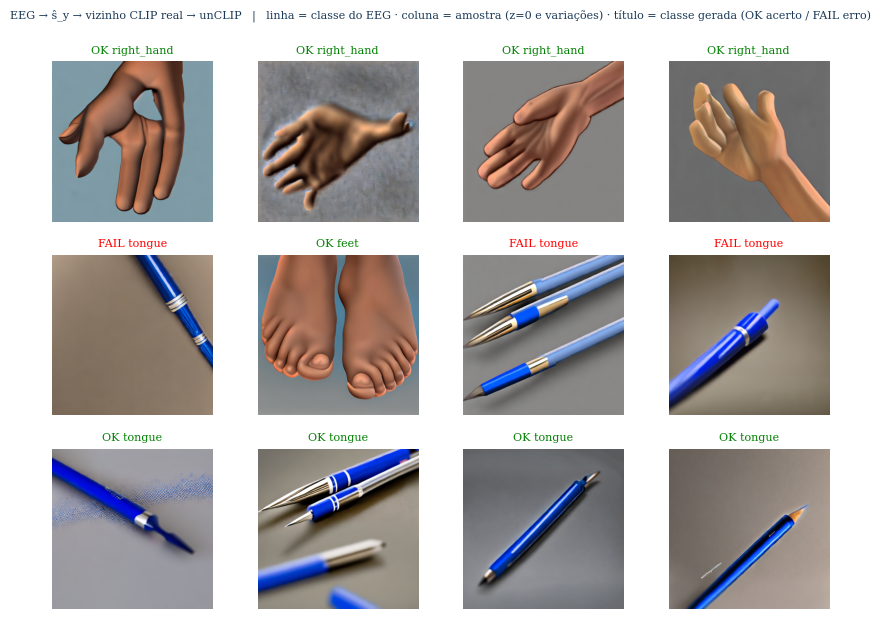

In [12]:
# ===== Célula 10 — EEG -> ŝ_y -> vizinho CLIP real (on-manifold) -> unCLIP =====
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
model.eval()

def norm_batch(x):
    m = x.mean(-1, keepdim=True); s = x.std(-1, keepdim=True) + 1e-6
    return (x - m) / s

@torch.no_grad()
def predict_clip(eeg, z=None):
    s_x = model.x_enc(norm_batch(eeg).to(device))
    if z is None: z = torch.zeros(s_x.shape[0], model.z_dim, device=device)
    return model.predictor(s_x, z)                       # ŝ_y padronizado

# Galeria de embeddings CLIP reais (padronizados) + rótulos
gal = torch.cat([sy_train[c] for c in range(len(CLASSES))]).to(device)
gal_lab = np.concatenate([[c]*sy_train[c].shape[0] for c in range(len(CLASSES))])

# Acurácia do ŝ_y
mk = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
shat_tr = predict_clip(eeg_t[train_idx]).cpu().numpy(); ytr = y_t[train_idx].numpy()
shat_va = predict_clip(eeg_t[val_idx]).cpu().numpy();   yva = y_t[val_idx].numpy()
acc = (mk().fit(shat_tr, ytr).predict(shat_va) == yva).mean()
print("Acurácia EEG->classe (ŝ_y): %.3f  (chance=%.3f)" % (acc, 1/len(CLASSES)))

# Geração: ŝ_y -> vizinho real mais próximo -> unstd -> unCLIP
val_eeg_by_class = {c: eeg_t[val_idx][y_t[val_idx] == c] for c in range(len(CLASSES))}
NS = 4
fig, axes = plt.subplots(len(CLASSES), NS, figsize=(NS*2.1, len(CLASSES)*2.1))
for r in range(len(CLASSES)):
    e = val_eeg_by_class[r][:1].repeat(NS, 1, 1)
    z = torch.cat([torch.zeros(1, model.z_dim, device=device),
                   torch.randn(NS-1, model.z_dim, device=device)], 0)
    shat = predict_clip(e, z)                                  # (NS, 768) padronizado
    nn = torch.cdist(shat, gal).argmin(1)                      # vizinho real on-manifold
    chosen = unstd(gal[nn])                                    # volta à escala CLIP real
    imgs = unclip_generate(chosen, steps=20, seed=r)
    for k in range(NS):
        pc = int(gal_lab[nn[k].item()])                        # classe do vizinho escolhido
        axes[r, k].imshow(imgs[k]); axes[r, k].axis("off")
        axes[r, k].set_title(("OK " if pc == r else "FAIL ") + CLASSES[pc], fontsize=8,
                             color=("green" if pc == r else "red"))
    axes[r, 0].set_ylabel("EEG:\n" + CLASSES[r], fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle("EEG → ŝ_y → vizinho CLIP real → unCLIP   |   linha = classe do EEG · "
             "coluna = amostra (z=0 e variações) · título = classe gerada (OK acerto / FAIL erro)",
             fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
print("val:", len(val_idx), "| por classe:", np.bincount(y_t[val_idx].numpy()))

val: 216 | por classe: [72 72 72]


In [13]:
from sklearn.metrics import confusion_matrix
clf = mk().fit(shat_tr, ytr); pred = clf.predict(shat_va)
cm = confusion_matrix(yva, pred)
print(cm)
for c in range(len(CLASSES)):
    print(f"{CLASSES[c]:10s}: {cm[c,c]/cm[c].sum():.2f}")

[[69  2  1]
 [ 0 43 29]
 [ 0 26 46]]
right_hand: 0.96
feet      : 0.60
tongue    : 0.64


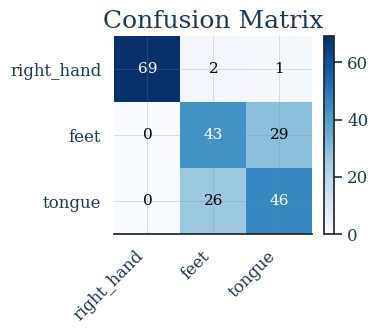

In [19]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,3.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
# ax.set_xlabel("classe predita"); ax.set_ylabel("classe real do EEG")
thr = cm.max()/2
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thr else "black", fontsize=11)
ax.set_title(f"Confusion Matrix")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.savefig("confusao.png", dpi=150); plt.show()

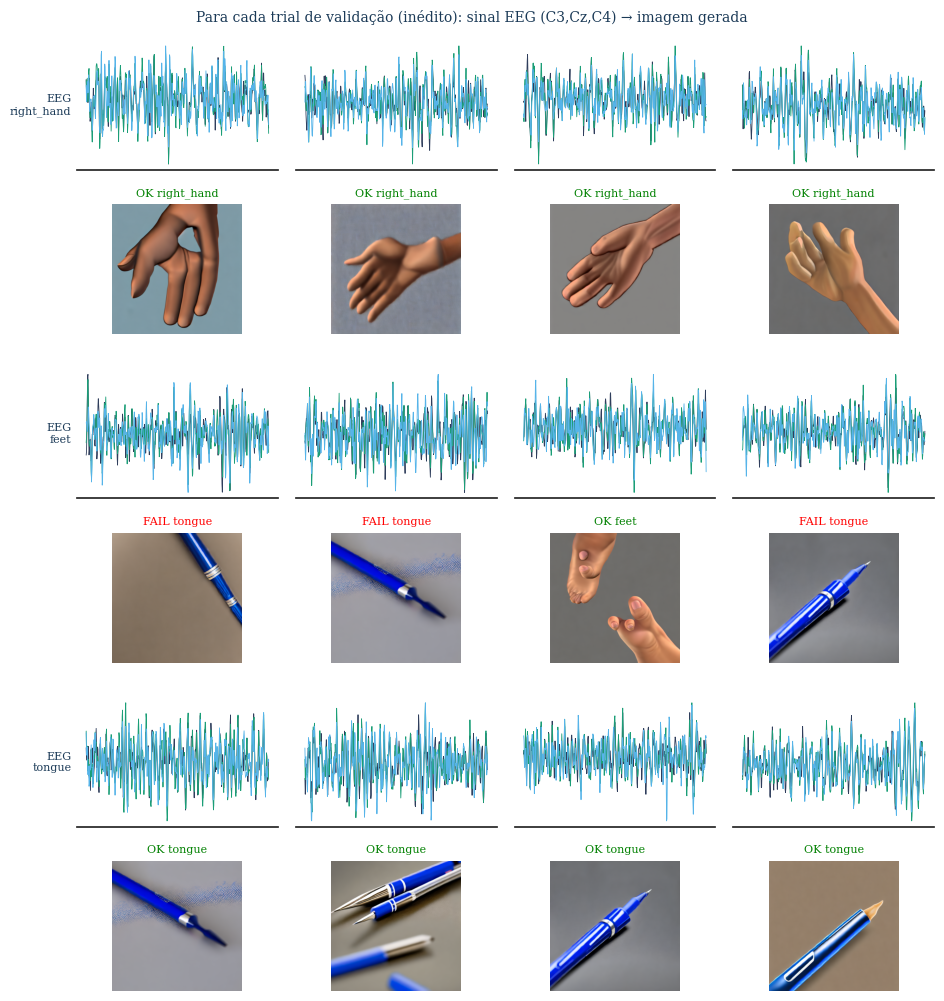

In [20]:
# ===== Célula 10 — EEG (entrada) + imagem gerada (saída), por trial de validação =====
model.eval()
gal = torch.cat([sy_train[c] for c in range(len(CLASSES))]).to(device)
gal_lab = np.concatenate([[c]*sy_train[c].shape[0] for c in range(len(CLASSES))])

N_TRIALS_SHOW = 4                 # trials de validação por classe
CHANS_SHOW = [7, 9, 11]           # C3, Cz, C4 (trio motor)
SFREQ = 128; t_axis = np.arange(N_TIMES) / SFREQ
val_eeg_by_class = {c: eeg_t[val_idx][y_t[val_idx] == c] for c in range(len(CLASSES))}

# 2 linhas por classe (sinal em cima, imagem embaixo), N_TRIALS_SHOW colunas
fig, axes = plt.subplots(len(CLASSES)*2, N_TRIALS_SHOW,
                         figsize=(N_TRIALS_SHOW*2.4, len(CLASSES)*2*1.7))
for r in range(len(CLASSES)):
    eegs = val_eeg_by_class[r][:N_TRIALS_SHOW]
    z = torch.zeros(eegs.shape[0], model.z_dim, device=device)
    with torch.no_grad():
        shat = model.predictor(model.x_enc(norm_batch(eegs).to(device)), z)
    nn = torch.cdist(shat, gal).argmin(1)
    imgs = unclip_generate(unstd(gal[nn]), steps=20, seed=r)
    row_sig, row_img = 2*r, 2*r + 1
    for k in range(eegs.shape[0]):
        # linha de cima: sinal EEG
        axs = axes[row_sig, k]
        for ch in CHANS_SHOW:
            axs.plot(t_axis, eegs[k, ch].numpy(), lw=0.6)
        axs.set_xticks([]); axs.set_yticks([])
        if k == 0: axs.set_ylabel("EEG\n" + CLASSES[r], fontsize=8, rotation=0, ha="right", va="center")
        # linha de baixo: imagem gerada
        axi = axes[row_img, k]
        pc = int(gal_lab[nn[k].item()])
        axi.imshow(imgs[k]); axi.axis("off")
        axi.set_title(("OK " if pc == r else "FAIL ") + CLASSES[pc], fontsize=8,
                      color=("green" if pc == r else "red"))
fig.suptitle("Para cada trial de validação (inédito): sinal EEG (C3,Cz,C4) → imagem gerada", fontsize=10)
plt.tight_layout(); plt.show()

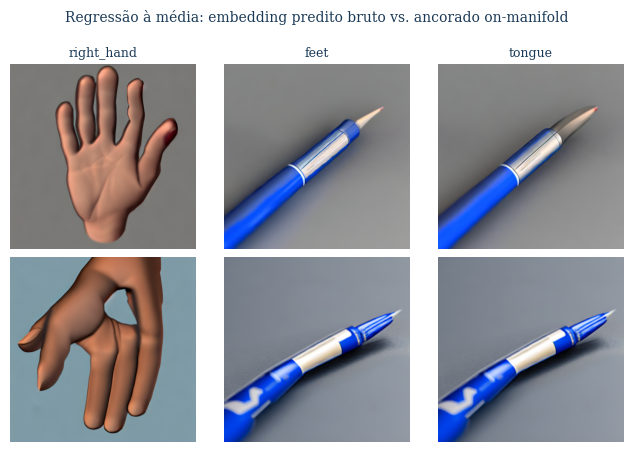

In [16]:
# Compara: embedding predito BRUTO (fora da variedade) vs ANCORADO on-manifold
NSHOW = len(CLASSES)
fig, axes = plt.subplots(2, NSHOW, figsize=(NSHOW*2.2, 4.6))
for r in range(NSHOW):
    e = val_eeg_by_class[r][:1]
    shat = predict_clip(e)                              # ŝ_y padronizado (média da classe)
    # (a) decodificação DIRETA do embedding predito (sem ancoragem)
    img_raw = unclip_generate(unstd(shat), steps=20, seed=0)[0]
    # (b) ancoragem on-manifold (vizinho real)
    nn = torch.cdist(shat, gal).argmin(1)
    img_anchor = unclip_generate(unstd(gal[nn]), steps=20, seed=0)[0]
    axes[0, r].imshow(img_raw);    axes[0, r].axis("off"); axes[0, r].set_title(CLASSES[r], fontsize=9)
    axes[1, r].imshow(img_anchor); axes[1, r].axis("off")
axes[0,0].set_ylabel("bruto\n(fora da\nvariedade)", fontsize=8, rotation=0, ha="right", va="center")
axes[1,0].set_ylabel("on-manifold", fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle("Regressão à média: embedding predito bruto vs. ancorado on-manifold", fontsize=10)
plt.tight_layout(); plt.savefig("onmanifold.png", dpi=150); plt.show()